In [11]:
# Imports and Configurations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.interpolate import interp1d
from scipy.integrate import quad
from scipy.stats import norm
from scipy.optimize import brentq
import warnings, sys, json, types, io, contextlib
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True,
    'grid.alpha': 0.3, 'font.size': 11,
})

BETA_SABR = 0.75

# == Import Part 1/2 notebooks as modules ======================================
def import_notebook_as_module(nb_path, module_name):
    with open(nb_path, encoding='utf-8') as f:
        nb_content = json.load(f)
    module = types.ModuleType(module_name)
    module.__file__ = nb_path
    code_lines = []
    for cell in nb_content['cells']:
        if cell['cell_type'] == 'code':
            src = ''.join(cell['source']) if isinstance(cell['source'], list) else cell['source']
            # Remove display(), %magic, plt.show — handling multi-line display() calls
            out = []
            skip_depth = 0
            for line in src.split('\n'):
                stripped = line.strip()
                if stripped.startswith('%') or stripped.startswith('plt.show'):
                    continue
                if skip_depth == 0 and stripped.startswith('display('):
                    skip_depth = line.count('(') - line.count(')')
                    if skip_depth <= 0: skip_depth = 0
                    continue
                if skip_depth > 0:
                    skip_depth += line.count('(') - line.count(')')
                    if skip_depth <= 0: skip_depth = 0
                    continue
                out.append(line)
            code_lines.append('\n'.join(out))
    full_code = '\n\n'.join(code_lines)
    import matplotlib as _mpl
    _backend = _mpl.get_backend()
    _mpl.use('Agg')
    with contextlib.redirect_stdout(io.StringIO()):
        exec(compile(full_code, nb_path, 'exec'), module.__dict__)
    _mpl.use(_backend)
    sys.modules[module_name] = module
    return module

# == Import Part 1 =============================================================
print('Importing Part 1 (bootstrapping) ...')
part1 = import_notebook_as_module('part1_bootstrapping_swap_curves.ipynb', 'part1')

from part1 import (
    tenor_to_years, df_interp, build_payment_schedule,
    bootstrap_ois, bootstrap_term_sofr,
)
T_ois_arr  = part1.T_ois
DF_ois_arr = part1.DF_ois
fwd_t_p1   = part1.fwd_t
fwd_r_p1   = part1.fwd_r

print(f'  OIS curve: {len(T_ois_arr)-1} pillars')
print(f'  Term SOFR: {len(fwd_t_p1)} quarterly forward rates')

# == Import Part 2 =============================================================
print('\nImporting Part 2 (swaption calibration) ...')
part2 = import_notebook_as_module('part2_swaption_calibration.ipynb', 'part2')

from part2 import (
    black_price, black_iv, sabr_vol,
    fwd_swap_rate, annuity,
)

# Retrieve calibrated SABR parameters and discount callables from Part 2
D_ois = part2.D_ois
D_ts  = part2.D_ts
swaption_slices = part2.swaption_slices

print(f'  Swaption slices: {len(swaption_slices)}')
print(f'  SABR params available: {all("sabr_params" in sl for sl in swaption_slices)}')

# Verify curves match
print('\nCurve check points:')
print(f'  {"T":>4}  {"D_OIS":>10}  {"D_TS":>10}')
print('  ' + '-' * 28)
for t in [1, 5, 10, 20, 30, 50]:
    print(f'  {t:>4}  {D_ois(t):>10.6f}  {D_ts(t):>10.6f}')

print('\nPart 1 + Part 2 imported successfully.')


Importing Part 1 (bootstrapping) ...
  OIS curve: 32 pillars
  Term SOFR: 120 quarterly forward rates

Importing Part 2 (swaption calibration) ...
  Swaption slices: 16
  SABR params available: True

Curve check points:
     T       D_OIS        D_TS
  ----------------------------
     1    0.966224    0.955360
     5    0.839451    0.824353
    10    0.680901    0.680525
    20    0.427583    0.444666
    30    0.282910    0.293202
    50    0.151716    0.118980

Part 1 + Part 2 imported successfully.


---
## SABR Parameter Interpolation

CMS pricing requires SABR parameters at arbitrary (expiry, tenor) pairs — not just the
calibrated grid points from Part II. We build bilinear interpolators across the calibrated
nodes so that `get_sabr_params(T_exp, T_ten)` returns smooth $(\alpha, \beta, \rho, \nu)$
for any expiry/tenor combination.


In [12]:
# == Build SABR parameter interpolators from Part 2 calibration =================
# Extract calibrated SABR params into a dict keyed by (T_exp, T_ten)
sabr_calib = {}
for sl in swaption_slices:
    if 'sabr_params' in sl:
        a, b, rho, nu = sl['sabr_params']
        sabr_calib[(sl['T_exp'], sl['T_ten'])] = {'alpha': a, 'rho': rho, 'nu': nu}

_exp_nodes = sorted(set(k[0] for k in sabr_calib))
_ten_nodes = sorted(set(k[1] for k in sabr_calib))

def _build_interp(key):
    d = {}
    for Tn in _ten_nodes:
        xs = [Te for Te in _exp_nodes if (Te, Tn) in sabr_calib]
        ys = [sabr_calib[(Te, Tn)][key] for Te in xs]
        if len(xs) >= 2:
            d[Tn] = interp1d(xs, ys, kind='linear', fill_value='extrapolate')
    return d

_ai = _build_interp('alpha')
_ri = _build_interp('rho')
_ni = _build_interp('nu')

def get_sabr_params(T_exp, T_ten):
    """Bilinear interpolation of SABR params for arbitrary (T_exp, T_ten)."""
    def _interp_over_tenor(interps, Te):
        xs = sorted(interps)
        ys = [float(interps[t](Te)) for t in xs]
        if len(xs) > 1:
            return float(interp1d(xs, ys, kind='linear', fill_value='extrapolate')(T_ten))
        return ys[0]
    return (
        _interp_over_tenor(_ai, T_exp),
        BETA_SABR,
        _interp_over_tenor(_ri, T_exp),
        _interp_over_tenor(_ni, T_exp),
    )

# Verify: compare interpolated vs calibrated for a known node
a_chk, _, rho_chk, nu_chk = get_sabr_params(10.0, 10.0)
sl_10x10 = next(s for s in swaption_slices if s['T_exp'] == 10.0 and s['T_ten'] == 10.0)
a_cal, _, rho_cal, nu_cal = sl_10x10['sabr_params']
print(f'SABR interpolation check (10Yx10Y):')
print(f'  Calibrated:    alpha={a_cal:.4f}  rho={rho_cal:+.4f}  nu={nu_cal:.4f}')
print(f'  Interpolated:  alpha={a_chk:.4f}  rho={rho_chk:+.4f}  nu={nu_chk:.4f}')
print(f'  Match: {np.allclose([a_cal, rho_cal, nu_cal], [a_chk, rho_chk, nu_chk], atol=1e-6)}')

print(f'\nSABR interpolation ready: {len(_exp_nodes)} expiry x {len(_ten_nodes)} tenor nodes')


SABR interpolation check (10Yx10Y):
  Calibrated:    alpha=0.1086  rho=-0.4318  nu=0.4288
  Interpolated:  alpha=0.1086  rho=-0.4318  nu=0.4288
  Match: True

SABR interpolation ready: 4 expiry x 6 tenor nodes


---
## CMS Convexity Adjustment — Theory

### The CMS rate vs forward swap rate

Under the annuity measure, $E^A[S_T] = F_S$ (the forward swap rate). But a CMS coupon pays
$S_T$ discounted at the OIS zero-coupon rate, not the annuity. The measure change from the
annuity measure to the payment-date measure introduces a **convexity adjustment**:

$$\text{CMS Rate} = E^{T_{\text{pay}}}[S_T] = F_S + \text{convexity adjustment}$$

### Static replication via $h''(K)$

Define $h(K) = K / \text{IRR}(K)$ where IRR is the internal rate of return annuity.
By Carr-Madan replication (Tee & Kerkhof, Eq 2.22):

$$\text{Conv. Adj.} = \frac{1}{D_{\text{OIS}}(T_{\text{pay}})} \left[
\int_0^{F_S} h''(K)\,V_{\text{rec}}(K)\,dK +
\int_{F_S}^{\infty} h''(K)\,V_{\text{pay}}(K)\,dK \right]$$

where $V_{\text{pay/rec}}(K)$ are swaption prices computed using SABR-calibrated vols from Part II,
and the **OIS-anchored IRR annuity** is:

$$\text{IRR}(S, n, T_e) = D_{\text{OIS}}(T_e) \cdot \frac{1 - (1+S)^{-n}}{S}$$


In [13]:
# == IRR annuity and derivatives (OIS-anchored) =================================
def IRR_annuity(S, n, T_exp):
    """OIS-anchored IRR annuity: D_OIS(T_exp) * (1 - (1+S)^-n) / S"""
    D_anc = D_ois(T_exp)
    if abs(S) < 1e-10:
        return D_anc * float(n)
    return D_anc * (1.0 - (1.0 + S)**(-n)) / S

def IRR_deriv1(S, n, T_exp):
    """d(IRR)/dS — analytical."""
    D_anc = D_ois(T_exp)
    if abs(S) < 1e-10:
        return -D_anc * n * (n + 1) / 2.0
    raw = (n * (1.0 + S)**(-(n+1)) - (1.0 - (1.0 + S)**(-n)) / S) / S
    return D_anc * raw

def IRR_deriv2(S, n, T_exp, dS=1e-5):
    """d^2(IRR)/dS^2 — central finite difference on IRR_deriv1."""
    return (IRR_deriv1(S + dS, n, T_exp) - IRR_deriv1(S - dS, n, T_exp)) / (2 * dS)

def h_double_prime(K, n, T_exp):
    """
    h''(K) where h(K) = K / IRR(K).
    h''(K) = [-IRR''*K - 2*IRR'] / IRR^2 + 2*K*IRR'^2 / IRR^3
    (Tee & Kerkhof Eq 2.22)
    """
    I   = IRR_annuity(K, n, T_exp)
    Ip  = IRR_deriv1(K, n, T_exp)
    Ipp = IRR_deriv2(K, n, T_exp)
    return (-Ipp * K - 2 * Ip) / I**2 + 2 * K * Ip**2 / I**3


# == CMS convexity adjustment via static replication ============================
def cms_conv_adj(T_exp, T_ten, T_pay, sabr_p):
    """
    CMS convexity adjustment via h''(K) static replication.
    Multi-curve: Term SOFR forward (from Part 1/2), OIS discounting, OIS-anchored IRR.

    Parameters
    ----------
    T_exp : float — swaption expiry (= CMS fixing date)
    T_ten : float — underlying swap tenor
    T_pay : float — CMS payment date
    sabr_p : tuple — (alpha, beta, rho, nu) SABR parameters

    Returns
    -------
    (F_S, conv_adj, cms_rate)
    """
    a, b, rho, nu = sabr_p
    F_S   = fwd_swap_rate(T_exp, T_ten, D_ois, D_ts)
    n     = int(round(T_ten))
    IRR_F = IRR_annuity(F_S, n, T_exp)
    D_T   = D_ois(T_pay)

    K_lo = max(F_S * 0.05, 1e-4)
    K_hi = F_S * 6.0

    def payer_integrand(K):
        sigma = sabr_vol(F_S, K, T_exp, a, b, rho, nu)
        V_pay = D_T * IRR_F * black_price(F_S, K, T_exp, sigma, A=1.0, is_payer=True)
        return h_double_prime(K, n, T_exp) * V_pay

    def recv_integrand(K):
        sigma = sabr_vol(F_S, K, T_exp, a, b, rho, nu)
        V_rec = D_T * IRR_F * black_price(F_S, K, T_exp, sigma, A=1.0, is_payer=False)
        return h_double_prime(K, n, T_exp) * V_rec

    try:
        I_pay, _ = quad(payer_integrand, F_S, K_hi, limit=200)
        I_rec, _ = quad(recv_integrand, K_lo, F_S, limit=200)
    except:
        I_pay = I_rec = 0.0

    conv_adj = (I_rec + I_pay) / D_T
    return F_S, conv_adj, F_S + conv_adj

print('CMS functions ready (multi-curve + h"(K) replication + OIS-anchored IRR).')


CMS functions ready (multi-curve + h"(K) replication + OIS-anchored IRR).


---
## Part III.1 — PV of CMS Legs

Two CMS products to value:
1. **CMS 10Y semi-annual** — receiving CMS10Y rate every 6 months for 5 years
2. **CMS 2Y quarterly** — receiving CMS2Y rate every 3 months for 10 years

For each payment date $t_i$:
$$\text{PV contribution}_i = D_{\text{OIS}}(0, t_i) \times \text{CMS Rate}(t_i) \times \Delta t$$

where CMS Rate = Forward Swap Rate + Convexity Adjustment.


In [14]:
# == CMS 10Y semi-annual — 5-year leg ===========================================
print('=' * 70)
print('III.1a — CMS 10Y semi-annual, 5-year leg')
print('        [Multi-curve + h"(K) static replication]')
print('=' * 70)

rows1 = []
pv1 = 0.0
for t in np.arange(0.5, 5.0 + 1e-9, 0.5):
    p = get_sabr_params(t, 10.0)
    F_S, adj, cms = cms_conv_adj(t, 10.0, t, p)
    d = D_ois(t)
    pv_pmt = d * cms * 0.5
    pv1 += pv_pmt
    rows1.append({
        'Pay Date': f'{t:.2f}Y',
        'Fwd Swap Rate (%)': f'{F_S*100:.4f}',
        'Conv. Adj (bps)': f'{adj*1e4:.2f}',
        'CMS Rate (%)': f'{cms*100:.4f}',
        'D_OIS(0,t)': f'{d:.6f}',
        'PV Contrib (bps)': f'{pv_pmt*1e4:.4f}',
    })

df1 = pd.DataFrame(rows1)
display(df1.style
    .set_caption('CMS 10Y Semi-Annual Leg — 5 Years')
    .hide(axis='index')
)

print(f'\n  Total PV = {pv1*1e4:.4f} bps = {pv1*100:.6f}% of notional')


III.1a — CMS 10Y semi-annual, 5-year leg
        [Multi-curve + h"(K) static replication]


Pay Date,Fwd Swap Rate (%),Conv. Adj (bps),CMS Rate (%),"D_OIS(0,t)",PV Contrib (bps)
0.50Y,3.8467,2.48,3.8715,0.982241,190.1355
1.00Y,3.8120,5.70,3.8690,0.966224,186.9140
1.50Y,3.8235,9.87,3.9222,0.950823,186.4661
2.00Y,3.8355,14.64,3.9818,0.935329,186.2169
2.50Y,3.8620,19.55,4.0575,0.919544,186.5545
3.00Y,3.8896,24.11,4.1308,0.903760,186.6610
3.50Y,3.9331,28.18,4.2149,0.887731,187.0866
4.00Y,3.9785,31.55,4.2939,0.871702,187.1509
4.50Y,4.0299,34.27,4.3725,0.855576,187.0511
5.00Y,4.0836,36.41,4.4476,0.839451,186.6788



  Total PV = 1870.9155 bps = 18.709155% of notional


In [15]:
# == CMS 2Y quarterly — 10-year leg =============================================
print('=' * 70)
print('III.1b — CMS 2Y quarterly, 10-year leg')
print('        [Multi-curve + h"(K) static replication]')
print('=' * 70)

rows2 = []
pv2 = 0.0
for t in np.arange(0.25, 10.0 + 1e-9, 0.25):
    p = get_sabr_params(t, 2.0)
    F_S, adj, cms = cms_conv_adj(t, 2.0, t, p)
    d = D_ois(t)
    pv_pmt = d * cms * 0.25
    pv2 += pv_pmt
    rows2.append({
        'Pay Date': f'{t:.2f}Y',
        'Fwd Swap Rate (%)': f'{F_S*100:.4f}',
        'Conv. Adj (bps)': f'{adj*1e4:.2f}',
        'CMS Rate (%)': f'{cms*100:.4f}',
        'D_OIS(0,t)': f'{d:.6f}',
        'PV Contrib (bps)': f'{pv_pmt*1e4:.4f}',
    })

df2 = pd.DataFrame(rows2)
# Show first 8 + last 4 rows to keep it readable (40 rows total)
display(pd.concat([df2.head(8), df2.tail(4)]).style
    .set_caption('CMS 2Y Quarterly Leg — 10 Years (showing first 8 + last 4 of 40 payments)')
    .hide(axis='index')
)

print(f'\n  Total PV = {pv2*1e4:.4f} bps = {pv2*100:.6f}% of notional')


III.1b — CMS 2Y quarterly, 10-year leg
        [Multi-curve + h"(K) static replication]


Pay Date,Fwd Swap Rate (%),Conv. Adj (bps),CMS Rate (%),"D_OIS(0,t)",PV Contrib (bps)
0.25Y,4.1854,0.59,4.1913,0.990934,103.8318
0.50Y,4.0652,1.84,4.0836,0.982241,100.2764
0.75Y,3.9431,4.06,3.9837,0.974054,97.0075
1.00Y,3.8189,6.93,3.8882,0.966224,93.9208
1.25Y,3.7640,10.24,3.8664,0.958523,92.6505
1.50Y,3.7081,13.49,3.8430,0.950823,91.3513
1.75Y,3.6513,16.42,3.8155,0.943076,89.9579
2.00Y,3.5934,18.89,3.7823,0.935329,88.4414
9.25Y,4.1707,62.26,4.7933,0.703933,84.3534
9.50Y,4.1952,64.58,4.8410,0.696256,84.2645



  Total PV = 3461.8136 bps = 34.618136% of notional


In [16]:
# == III.1 Summary ==============================================================
print('=' * 50)
print('  III.1 — CMS Leg PV Summary')
print('=' * 50)
print(f'  CMS 10Y semi-annual (5yr):  PV = {pv1*1e4:.4f} bps')
print(f'  CMS 2Y  quarterly  (10yr): PV = {pv2*1e4:.4f} bps')
print('=' * 50)


  III.1 — CMS Leg PV Summary
  CMS 10Y semi-annual (5yr):  PV = 1870.9155 bps
  CMS 2Y  quarterly  (10yr): PV = 3461.8136 bps


---
## Part III.2 — Forward Swap Rate vs CMS Rate

Compare forward swap rates with CMS rates for the following pairs:
- $1 \times 1$, $1 \times 10$
- $5 \times 1$, $5 \times 10$
- $10 \times 1$, $10 \times 10$

The convexity correction = CMS Rate $-$ Forward Swap Rate.


In [17]:
# == Forward swap rate vs CMS rate comparison ===================================
pairs = [(1, 1), (1, 10), (5, 1), (5, 10), (10, 1), (10, 10)]

rows = []
for Te, Tn in pairs:
    p = get_sabr_params(float(Te), float(Tn))
    F_S, adj, cms = cms_conv_adj(float(Te), float(Tn), float(Te), p)
    rows.append({
        'Expiry x Tenor': f'{Te}Y x {Tn}Y',
        'Fwd Swap Rate (%)': round(F_S * 100, 5),
        'CMS Rate (%)': round(cms * 100, 5),
        'Conv. Adj. (bps)': round(adj * 1e4, 3),
        'Adj / Fwd (%)': round(adj / F_S * 100, 3),
    })

df_cmp = pd.DataFrame(rows)
display(df_cmp.style
    .format({'Fwd Swap Rate (%)': '{:.4f}%', 'CMS Rate (%)': '{:.4f}%',
             'Conv. Adj. (bps)': '{:.3f}', 'Adj / Fwd (%)': '{:.3f}%'})
    .set_caption('III.2 — Convexity Correction: Forward Swap Rate vs CMS Rate')
    .hide(axis='index')
)


Expiry x Tenor,Fwd Swap Rate (%),CMS Rate (%),Conv. Adj. (bps),Adj / Fwd (%)
1Y x 1Y,3.9768%,4.0381%,6.132,1.542%
1Y x 10Y,3.8120%,3.8690%,5.698,1.495%
5Y x 1Y,3.6905%,3.9109%,22.035,5.971%
5Y x 10Y,4.0836%,4.4476%,36.408,8.916%
10Y x 1Y,4.1493%,4.6457%,49.632,11.961%
10Y x 10Y,4.4205%,5.4664%,104.592,23.661%


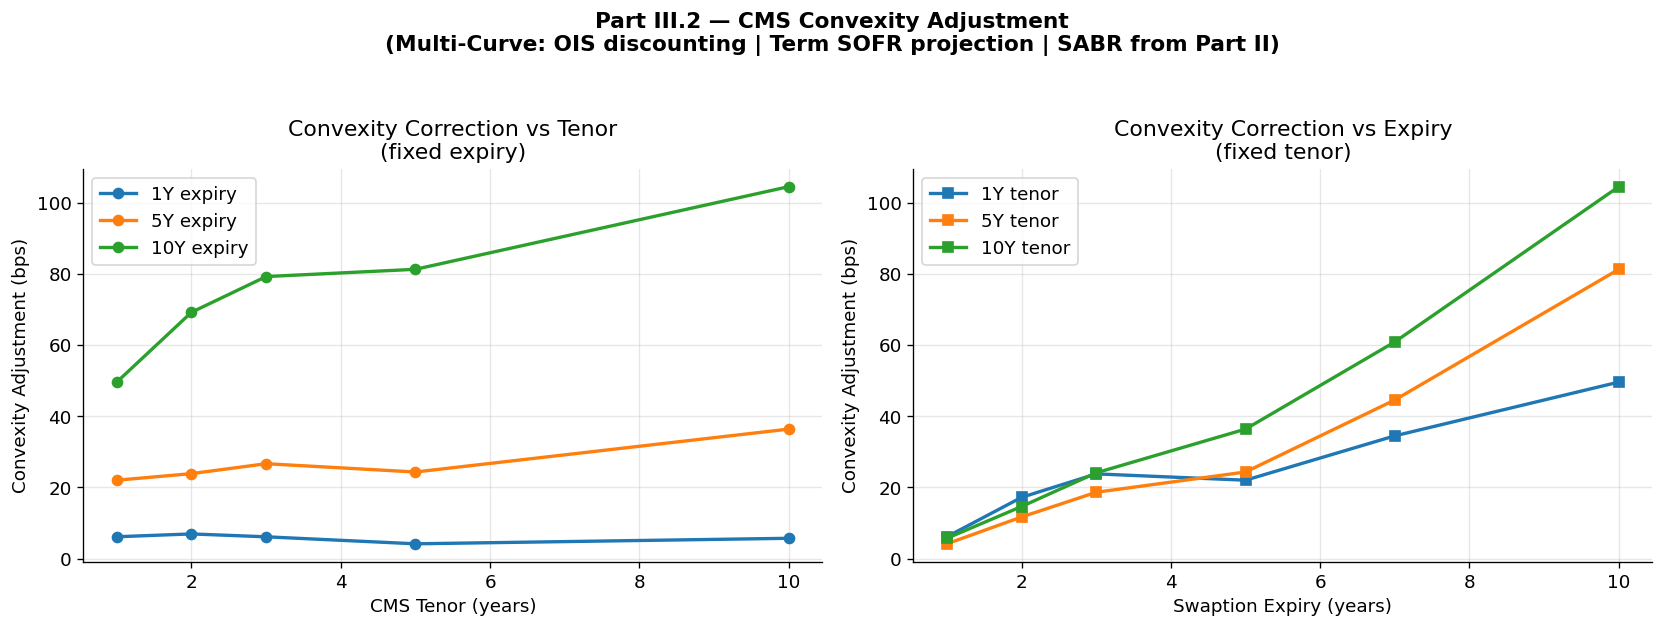

In [20]:
# == Convexity adjustment plots ==================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
tenors_p = [1, 2, 3, 5, 10]
expiries_p = [1, 5, 10]

# Left: convexity vs tenor (fixed expiry)
ax = axes[0]
for Te in expiries_p:
    adjs = []
    for Tn in tenors_p:
        p = get_sabr_params(float(Te), float(Tn))
        _, adj, _ = cms_conv_adj(float(Te), float(Tn), float(Te), p)
        adjs.append(adj * 1e4)
    ax.plot(tenors_p, adjs, marker='o', lw=2, label=f'{Te}Y expiry')
ax.set_xlabel('CMS Tenor (years)')
ax.set_ylabel('Convexity Adjustment (bps)')
ax.set_title('Convexity Correction vs Tenor\n(fixed expiry)')
ax.legend()

# Right: convexity vs expiry (fixed tenor)
ax = axes[1]
exp_range = [1, 2, 3, 5, 7, 10]
for Tn in [1, 5, 10]:
    adjs = []
    for Te in exp_range:
        p = get_sabr_params(float(Te), float(Tn))
        _, adj, _ = cms_conv_adj(float(Te), float(Tn), float(Te), p)
        adjs.append(adj * 1e4)
    ax.plot(exp_range, adjs, marker='s', lw=2, label=f'{Tn}Y tenor')
ax.set_xlabel('Swaption Expiry (years)')
ax.set_ylabel('Convexity Adjustment (bps)')
ax.set_title('Convexity Correction vs Expiry\n(fixed tenor)')
ax.legend()

fig.suptitle('Part III.2 — CMS Convexity Adjustment\n'
             '(Multi-Curve: OIS discounting | Term SOFR projection | SABR from Part II)',
             fontsize=13, fontweight='bold', y=1.04)
fig.tight_layout()
plt.show()


---
## Discussion — Effect of Maturity and Tenor on Convexity Correction

### Effect of Tenor (CMS10Y >> CMS2Y >> CMS1Y)

Longer underlying swap tenors produce larger convexity adjustments because:
- The IRR annuity function $\text{IRR}(S) = \frac{1 - (1+S)^{-n}}{S}$ becomes more **concave** as $n$ increases
- This means $h''(K)$ is larger, so the static replication integral picks up more swaption value
- Economically: a 10-year swap annuity is much more sensitive to rate movements than a 1-year annuity

### Effect of Expiry (longer expiry → larger adjustment)

Longer swaption expiry increases the convexity adjustment because:
- Higher option maturity means greater variance of $S_T$ under the payment measure
- This amplifies the Jensen's inequality effect: $E[h(S)] > h(E[S])$ when $h$ is convex
- The SABR model generates wider smiles at longer expiries, further increasing wing swaption values

### Combined Effect

The convexity correction is always **positive** (CMS rate > forward swap rate) because the
annuity function is concave in the swap rate. The adjustment is most significant for:
- Long tenor + long expiry combinations (e.g., 10×10)
- These are precisely the CMS products most actively traded in practice

### Multi-Curve Impact

Using separate OIS (discounting) and Term SOFR (projection) curves produces slightly different
convexity adjustments compared to a single-curve framework, because the OIS-anchored IRR annuity
$D_{\text{OIS}}(T_e) \cdot \frac{1 - (1+S)^{-n}}{S}$ properly reflects the collateralised
discounting environment.


In [19]:
print('=' * 70)
print(' Part III — Complete')
print('=' * 70)
print(f'\n  III.1a  CMS 10Y semi-annual (5yr leg):   PV = {pv1*1e4:.4f} bps')
print(f'  III.1b  CMS 2Y quarterly   (10yr leg):  PV = {pv2*1e4:.4f} bps')
print(f'\n  III.2   Convexity corrections computed for 6 (expiry, tenor) pairs')
print(f'          Tenor effect:  longer tenor -> larger adjustment (more IRR concavity)')
print(f'          Expiry effect: longer expiry -> larger adjustment (more rate variance)')
print('\n  Dependencies:')
print('    Part 1: OIS discount curve, Term SOFR projection curve')
print('    Part 2: SABR calibrated parameters, forward swap rates, Black-76 pricing')
print('=' * 70)


 Part III — Complete

  III.1a  CMS 10Y semi-annual (5yr leg):   PV = 1870.9155 bps
  III.1b  CMS 2Y quarterly   (10yr leg):  PV = 3461.8136 bps

  III.2   Convexity corrections computed for 6 (expiry, tenor) pairs
          Tenor effect:  longer tenor -> larger adjustment (more IRR concavity)
          Expiry effect: longer expiry -> larger adjustment (more rate variance)

  Dependencies:
    Part 1: OIS discount curve, Term SOFR projection curve
    Part 2: SABR calibrated parameters, forward swap rates, Black-76 pricing
